In [1]:
from google.colab import files
print("upload kaggle.json")
uploaded = files.upload()

upload kaggle.json


Saving kaggle (1).json to kaggle (1).json


In [2]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:42<00:00, 131MB/s]



In [3]:
!unzip -q skin-cancer-mnist-ham10000.zip -d ham10000

In [4]:
import os

dataset_path = "/content/ham10000"

for root, dirs, files in os.walk(dataset_path):
    print(root)
    print(f"{len(files)} files")

/content/ham10000
5 files
/content/ham10000/HAM10000_images_part_2
5015 files
/content/ham10000/ham10000_images_part_1
5000 files
/content/ham10000/HAM10000_images_part_1
5000 files
/content/ham10000/ham10000_images_part_2
5015 files


In [5]:
import os

os.listdir("/content/ham10000")

['HAM10000_images_part_2',
 'ham10000_images_part_1',
 'HAM10000_metadata.csv',
 'hmnist_8_8_L.csv',
 'HAM10000_images_part_1',
 'hmnist_28_28_L.csv',
 'hmnist_28_28_RGB.csv',
 'ham10000_images_part_2',
 'hmnist_8_8_RGB.csv']

In [6]:
import pandas as pd

metadata = pd.read_csv("/content/ham10000/HAM10000_metadata.csv")

print(metadata.shape)

metadata.head()

(10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [7]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [8]:
metadata["dx"].value_counts()

,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


In [9]:
metadata["dx"].unique()

array(['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec'], dtype=object)

In [10]:
import os
import matplotlib.pyplot as plt
from PIL import Image

image_dir1 = "/content/ham10000/HAM10000_images_part_1"
image_dir2 = "/content/ham10000/HAM10000_images_part_2"

metadata["path"] = metadata["image_id"].apply(
    lambda x: os.path.join(image_dir1, x + ".jpg")
    if os.path.exists(os.path.join(image_dir1, x + ".jpg"))
    else os.path.join(image_dir2, x + ".jpg")
)

metadata[["image_id", "dx", "path"]].head()

,image_id,dx,path
0,ISIC_0027419,bkl,/content/ham10000/HAM10000_images_part_1/ISIC_...
1,ISIC_0025030,bkl,/content/ham10000/HAM10000_images_part_1/ISIC_...
2,ISIC_0026769,bkl,/content/ham10000/HAM10000_images_part_1/ISIC_...
3,ISIC_0025661,bkl,/content/ham10000/HAM10000_images_part_1/ISIC_...
4,ISIC_0031633,bkl,/content/ham10000/HAM10000_images_part_2/ISIC_...


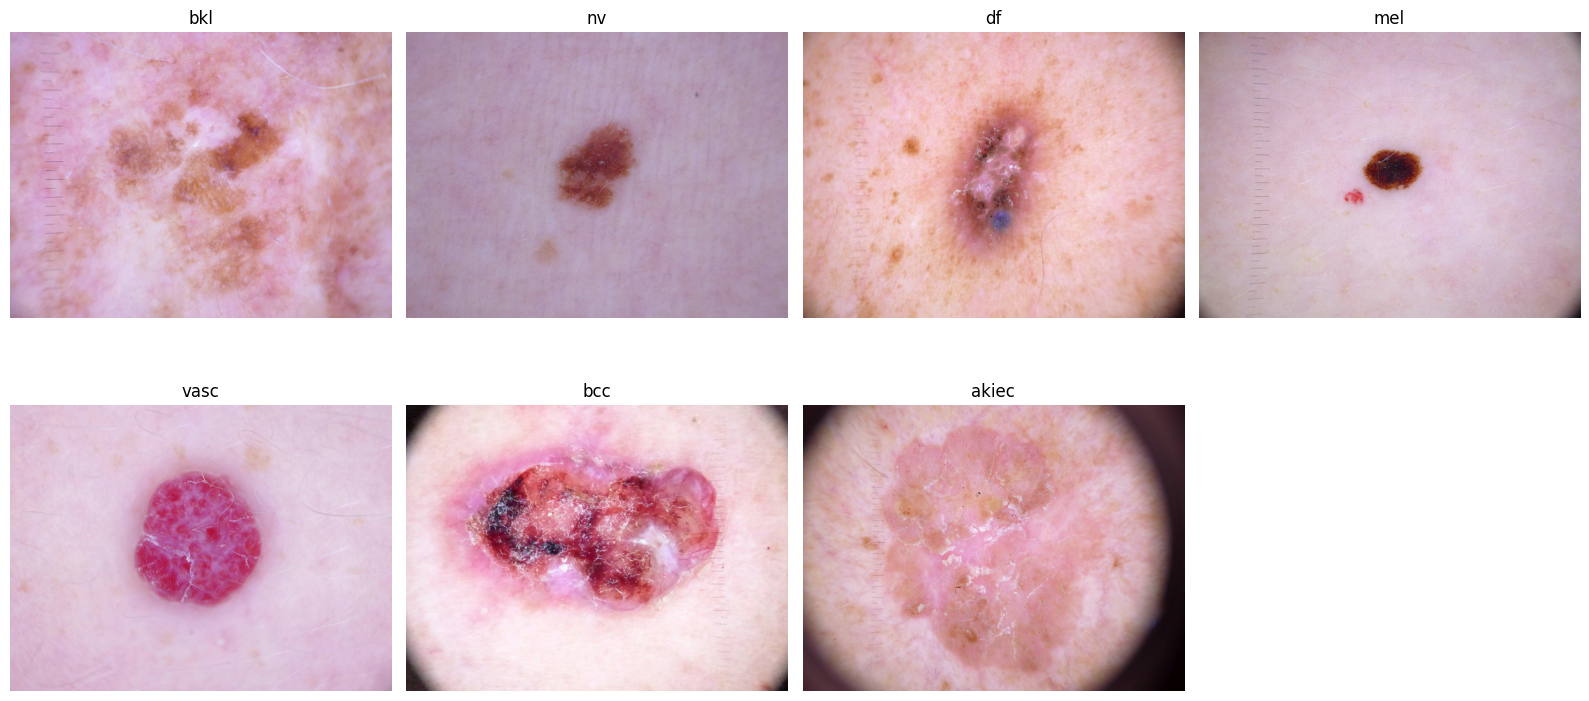

In [11]:
classes = metadata["dx"].unique()

plt.figure(figsize=(16,8))

for i, cls in enumerate(classes):
    sample = metadata[metadata["dx"] == cls].iloc[0]

    img = Image.open(sample["path"])

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    metadata,
    test_size=0.2,
    stratify=metadata["dx"],
    random_state=42
)

print("Training:", len(train_df))
print("Validation:", len(val_df))

Training: 8012
Validation: 2003


In [13]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

train_df["label"] = encoder.fit_transform(train_df["dx"])
val_df["label"] = encoder.transform(val_df["dx"])

print(encoder.classes_)

['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


In [14]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [17]:
from torch.utils.data import Dataset
from PIL import Image

class SkinDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(row["path"]).convert("RGB")

        label = row["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

In [18]:
from torch.utils.data import DataLoader

train_dataset = SkinDataset(train_df, train_transform)
val_dataset = SkinDataset(val_df, val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [19]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [20]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

In [21]:
weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 81.7MB/s]


In [22]:
for param in model.parameters():
    param.requires_grad = False

In [23]:
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 7)
)

In [25]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

criterion = nn.CrossEntropyLoss(weight=class_weights)

In [26]:
optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)

In [27]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [28]:
!pip install -q tqdm

In [29]:
from tqdm import tqdm
import copy

In [50]:
class EarlyStopping:

    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_loss = float("inf")
        self.early_stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0

        else:
            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True

In [31]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [32]:
def train_one_epoch(model, loader, optimizer, criterion):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [33]:
def validate(model, loader, criterion):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [39]:
print(device)
print(next(model.parameters()).device)

cuda
cpu


In [40]:
model = model.to(device)

In [41]:
print(next(model.parameters()).device)

cuda:0


In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print("Device:", device)
print("Model device:", next(model.parameters()).device)

Device: cuda
Model device: cuda:0


In [45]:
print(class_weights.device)
print(next(model.parameters()).device)
print(device)

cpu
cuda:0
cuda


In [46]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch.nn as nn

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

criterion = nn.CrossEntropyLoss(weight=class_weights)

In [47]:
print(class_weights.device)

cuda:0


In [51]:
num_epochs = 15

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_model = copy.deepcopy(model.state_dict())

best_acc = 0

early_stopping = EarlyStopping(patience=5)

for epoch in range(num_epochs):

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")

    if val_acc > best_acc:

        best_acc = val_acc

        best_model = copy.deepcopy(model.state_dict())

        torch.save(best_model, "best_resnet50_skin.pth")

        print("Best model saved!")

    early_stopping(val_loss)

    if early_stopping.early_stop:

        print("Early stopping!")

        break


Epoch 1/15


100%|██████████| 63/63 [00:22<00:00,  2.78it/s]


Train Loss : 1.1540
Train Acc  : 0.6110
Val Loss   : 1.0816
Val Acc    : 0.6710
Best model saved!

Epoch 2/15


100%|██████████| 63/63 [00:22<00:00,  2.80it/s]


Train Loss : 1.0802
Train Acc  : 0.6258
Val Loss   : 1.0301
Val Acc    : 0.6980
Best model saved!

Epoch 3/15


...

Train Loss : 0.8937
Train Acc  : 0.6570
Val Loss   : 0.9644
Val Acc    : 0.7314
Best model saved!

Epoch 14/15


100%|██████████| 63/63 [00:22<00:00,  2.86it/s]


Train Loss : 0.8428
Train Acc  : 0.6770
Val Loss   : 0.9035
Val Acc    : 0.6975

Epoch 15/15


100%|██████████| 63/63 [00:22<00:00,  2.84it/s]

Train Loss : 0.8073
Train Acc  : 0.6710
Val Loss   : 0.8750
Val Acc    : 0.6985
